In [1]:
import networkx as nx
from cdlib.algorithms import leiden, louvain, infomap, walktrap
from time import time

Note: to be able to use all crisp methods, you need to install some additional packages:  {'infomap', 'wurlitzer', 'graph_tool', 'bayanpy'}
Note: to be able to use all crisp methods, you need to install some additional packages:  {'ASLPAw', 'pyclustering'}
Note: to be able to use all crisp methods, you need to install some additional packages:  {'infomap', 'wurlitzer'}


In [2]:
def tic():
    return time()

def toc(start):
    return time() - start

In [3]:
G = nx.read_graphml("KRvKP_5_updated.graphml")
G = nx.convert_node_labels_to_integers(G)
print(f"n: {G.number_of_nodes()}")
print(f"m: {G.number_of_edges()}")

n: 19617
m: 75160


In [4]:
def save(G, filename):
    reverse_map = {node_id: data["label"] for node_id, data in G.nodes(data=True)}
    G_restored = nx.relabel_nodes(G, reverse_map)
    nx.write_graphml(G, f"{filename}.graphml")

In [5]:
def set_communities_to_graph(G, communities, algorithm_name):
    for i, c in enumerate(communities):
        for u in c:
            G.nodes[u][algorithm_name] = i

algorithms = {"louvain": louvain, "leiden": leiden, "infomap": infomap, "walktrap": walktrap}
results = {k: None for k in algorithms.keys()}

for algorithm_name, algorithm in algorithms.items():
    start = tic()
    try:
        result = algorithm(G)
        set_communities_to_graph(G, result.communities, algorithm_name)
    except TypeError as e:
        G_ = G.to_undirected()
        result = algorithm(G_)
        set_communities_to_graph(G, result.communities, algorithm_name)
    results[algorithm_name] = result
    t = toc(start)
    print(f"{algorithm_name}: {t:.2f}s")

louvain: 5.57s
leiden: 0.85s
infomap: 6.93s
walktrap: 7.14s


In [6]:
save(G, "KRvKP_5_updated_updated")

In [7]:
G.nodes[0]

{'label': '3r4/2k5/5P2/7K/8/8/8/8:b:2',
 'wdl': 2,
 'Modularity Class': 0,
 'Inferred Class': 25,
 'Cluster': 10,
 'size': 10.0,
 'r': 0,
 'g': 176,
 'b': 235,
 'x': 18.257175,
 'y': 335.86563,
 'louvain': 5,
 'leiden': 10,
 'infomap': 9,
 'walktrap': 2}

In [18]:
win_frequency = dict()
loss_frequency = dict()
draw_frequency = dict()

nodes = list(G.nodes())

result = results["leiden"]
communities = result.communities
communities = {i: c for i, c in enumerate(communities) if len(c)/len(nodes) >= 0.025}

for i, c in communities.items():
    wins = 0
    losses = 0
    draws = 0
    for u in c:
        if G.nodes[u]["wdl"] == 2:
            wins += 1
        elif G.nodes[u]["wdl"] == -2:
            losses += 1
        elif G.nodes[u]["wdl"] == 0:
            draws += 1
    win_frequency[i] = wins/len(c)
    loss_frequency[i] = losses/len(c)
    draw_frequency[i] = draws/len(c)

In [19]:
win_frequency = dict(sorted(win_frequency.items(), key=lambda item: -item[1]))
loss_frequency = dict(sorted(loss_frequency.items(), key=lambda item: -item[1]))
draw_frequency = dict(sorted(draw_frequency.items(), key=lambda item: -item[1]))

In [20]:
draw_frequency

{18: 0.9166666666666666,
 17: 0.9062087186261559,
 5: 0.6202964652223489,
 3: 0.4715909090909091,
 1: 0.4593867670790748,
 15: 0.4470868014268728,
 16: 0.4229390681003584,
 8: 0.33410138248847926,
 9: 0.31833910034602075,
 2: 0.30394736842105263,
 10: 0.2601626016260163,
 12: 0.22157092614302462,
 7: 0.19129438717067582,
 0: 0.18552036199095023,
 6: 0.12770809578107184,
 4: 0.07386363636363637,
 14: 0.06941176470588235,
 11: 0.06504065040650407,
 13: 0.045828437132784956}

In [10]:
win_frequency

{13: 0.9153936545240893,
 11: 0.8641114982578397,
 14: 0.8564705882352941,
 0: 0.7085218702865762,
 12: 0.7069167643610785,
 10: 0.6898954703832753,
 16: 0.5053763440860215,
 3: 0.4659090909090909,
 15: 0.46135552913198574,
 1: 0.4228079612694997,
 4: 0.41818181818181815,
 6: 0.3329532497149373,
 7: 0.27835051546391754,
 5: 0.2759407069555302,
 9: 0.16724336793540945,
 8: 0.13940092165898618,
 2: 0.12697368421052632,
 17: 0.09379128137384413,
 18: 0.08333333333333333}

In [11]:
loss_frequency

{2: 0.569078947368421,
 6: 0.5393386545039909,
 7: 0.5303550973654066,
 8: 0.5264976958525346,
 9: 0.5144175317185697,
 4: 0.5079545454545454,
 1: 0.1178052716514255,
 0: 0.1059577677224736,
 5: 0.10376282782212087,
 15: 0.09155766944114149,
 14: 0.07411764705882352,
 16: 0.07168458781362007,
 12: 0.07151230949589683,
 11: 0.07084785133565621,
 3: 0.0625,
 10: 0.04994192799070848,
 13: 0.038777908343125736,
 17: 0.0,
 18: 0.0}

In [90]:
def get_barycenter(G, community):
    G_ = G.subgraph(community)
    G_ = G_.to_undirected()
    return nx.barycenter(G_)[0]

In [67]:
barycenter = get_barycenter(G, result.communities[13])

In [68]:
G.nodes[barycenter]

{'label': '3r4/2k5/5P2/8/5K2/8/8/8:b:2',
 'wdl': 2,
 'Modularity Class': 0,
 'Inferred Class': 17,
 'Cluster': 7,
 'size': 10.0,
 'r': 255,
 'g': 87,
 'b': 255,
 'x': 531.94666,
 'y': 2833.6394,
 'louvain': 12,
 'leiden': 13,
 'infomap': 4,
 'walktrap': 6}

In [91]:
def get_barycenters(G, communities):
    return {i: get_barycenter(G, c) for i, c in communities.items()}

def get_edges_between_communities(G, communities):
    skeleton_edges = {(i, j): set() for i in communities.keys() for j in communities.keys() if i != j}

    comm = {u: i for i, c in communities.items() for u in c}
    for (u, v) in G.edges():
        c_u = comm.get(u, None)
        c_v = comm.get(v, None)
        if c_u == c_v or c_u is None or c_v is None:
            continue

        skeleton_edges[(c_u, c_v)].add((u, v))

    return skeleton_edges

In [92]:
skeleton_edges = get_edges_between_communities(G, communities)
skeleton_edges

{(0, 1): {(2037, 22),
  (2037, 23),
  (2038, 3861),
  (2038, 3862),
  (2039, 3787),
  (2039, 3788),
  (2190, 3895),
  (2190, 3896),
  (2191, 3825),
  (2191, 3826),
  (2192, 3747),
  (2192, 3748),
  (2335, 6644),
  (2335, 6645),
  (2336, 6618),
  (2336, 6619),
  (2472, 3963),
  (2472, 3964),
  (2473, 3929),
  (2473, 3930),
  (2593, 6828),
  (2594, 6826),
  (2595, 6824),
  (2595, 6825),
  (2596, 6822),
  (2596, 6823),
  (2597, 6820),
  (2597, 6821),
  (2598, 6816),
  (2598, 6817),
  (2599, 6812),
  (2599, 6813),
  (2600, 6796),
  (2600, 6797),
  (2601, 6788),
  (2601, 6789),
  (2602, 6768),
  (2602, 6769),
  (2603, 6746),
  (2603, 6747),
  (2604, 6724),
  (2604, 6725),
  (2605, 6702),
  (2605, 6703),
  (2606, 6680),
  (2606, 6681),
  (2607, 6662),
  (2607, 6663),
  (2608, 3995),
  (2608, 3996),
  (2742, 10662),
  (2742, 10663),
  (2743, 10634),
  (2743, 10635),
  (2857, 10836),
  (2858, 10834),
  (2859, 10832),
  (2859, 10833),
  (2860, 10830),
  (2860, 10831),
  (2861, 10828),
  (2861, 

In [93]:
barycenters = get_barycenters(G, communities)
barycenters

{0: 1893,
 1: 3912,
 2: 42,
 3: 4545,
 4: 1065,
 5: 4546,
 6: 1066,
 7: 1064,
 8: 1063,
 9: 1062,
 10: 0,
 11: 2892,
 12: 2889,
 13: 2890,
 14: 2891,
 15: 4547,
 16: 2887,
 17: 1070,
 18: 1069}

In [82]:
def get_skeleton_graph(G, communities):
    #barycenters = get_barycenters(G, communities)
    skeleton_edges = get_edges_between_communities(G, communities)

    G_skeleton = nx.DiGraph()

    for (c_u, c_v), edges in skeleton_edges.items():
        if len(edges) >= 1:
            G_skeleton.add_edge(c_u, c_v)

    for i, c in communities.items():
        u = c[0]
        G_skeleton.nodes[i]["x"] = G.nodes[u]["x"]
        G_skeleton.nodes[i]["y"] = G.nodes[u]["y"]
    
    return G_skeleton

def draw_skeleton_graph(G_skeleton, communities):
    pos = dict()
    for u, data in G_skeleton.nodes(data=True):
        x = data["x"]
        y = data["y"]
        pos[u] = (x, y)
        
    comm = {u: i for i, c in communities.items() for u in c}
    node_colors = []
    for c in G_skeleton.nodes():
        w = win_frequency.get(c, 0)
        l = loss_frequency.get(c, 0)
        d = draw_frequency.get(c, 0)
    
        wl = w + l
    
        r = l / wl
        g = w / wl
    
        r = r * (1 - d)
        g = g * (1 - d)
        
        node_colors.append((r, g, 0))
        
    return nx.draw(G_skeleton, pos=pos, node_color=node_colors, with_labels=True, font_color="white")

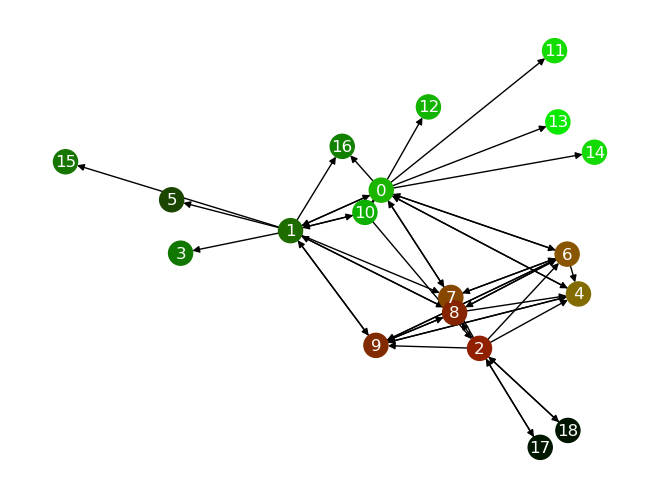

In [83]:
G_skeleton = get_skeleton_graph(G, communities)
draw_skeleton_graph(G_skeleton, communities)

In [108]:
start_node = 0 # 3r4/2k5/5P2/7K/8/8/8/8:b:2 <=> 3r4/2k5/5P2/7K/8/8/8/8 b - - 0 1
all_paths = nx.single_source_shortest_path(G, source=start_node)
barycenter_paths = {}

for comm_i, barycenter in barycenters.items():
    path = all_paths[barycenter]
    barycenter_paths[comm_i] = path

In [110]:
barycenter_paths

{0: [0, 1, 19163, 1893],
 1: [0, 1, 19181, 3912],
 2: [0, 2, 19501, 42],
 3: [0, 1, 19181, 3912, 4545],
 4: [0, 2, 19143, 2576, 1065],
 5: [0, 1, 19181, 3912, 4546],
 6: [0, 1, 19163, 1893, 1066],
 7: [0, 1, 19147, 2608, 1064],
 8: [0, 1, 19181, 3912, 1063],
 9: [0, 2, 19180, 3928, 1062],
 10: [0],
 11: [0, 1, 19163, 1893, 2892],
 12: [0, 1, 19147, 2608, 2889],
 13: [0, 1, 19163, 1893, 2890],
 14: [0, 1, 19163, 1893, 2891],
 15: [0, 1, 19181, 3912, 4547],
 16: [0, 1, 19181, 3912, 2887],
 17: [0, 2, 19501, 42, 1070],
 18: [0, 2, 19501, 42, 1069]}

In [129]:
# 1 - W + L
def get_community_scores():
    community_scores = dict()
    for comm_i in win_frequency.keys():
        w = win_frequency[comm_i]
        l = loss_frequency[comm_i]
        
        score = 1 - w + l
        community_scores[comm_i] = score
    return community_scores

In [131]:
# best/ideal community (by get_community_scores) to get to is 13
community_scores = get_community_scores()
community_scores = dict(sorted(win_frequency.items(), key=lambda item: -item[1]))
community_scores

{13: 0.9153936545240893,
 11: 0.8641114982578397,
 14: 0.8564705882352941,
 0: 0.7085218702865762,
 12: 0.7069167643610785,
 10: 0.6898954703832753,
 16: 0.5053763440860215,
 3: 0.4659090909090909,
 15: 0.46135552913198574,
 1: 0.4228079612694997,
 4: 0.41818181818181815,
 6: 0.3329532497149373,
 7: 0.27835051546391754,
 5: 0.2759407069555302,
 9: 0.16724336793540945,
 8: 0.13940092165898618,
 2: 0.12697368421052632,
 17: 0.09379128137384413,
 18: 0.08333333333333333}